In [1]:
import os
from config_and_utils import TOKENIZER_PATH

print("Tokenizer path:", TOKENIZER_PATH)
print("Exists:", os.path.exists(TOKENIZER_PATH))

No GPU detected. Running on CPU.
Tokenizer path: ../data/processed/tokenizer.pkl
Exists: True


In [2]:

# ─── CELL 1 — Imports ─────────────────────────────────────────────
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from config_and_utils import (
    clean_text, MaxoutLayer,
    JOINT_MODEL_PATH, TOKENIZER_PATH,
    MAX_SEQUENCE_LENGTH, THRESHOLD
)


In [3]:

# ─── CELL 2 — Prediction Pipeline (loads model once) ──────────────
class _Pipeline:
    """Lazy-loading singleton — loads model once, reuses on every call."""
    _instance = None

    def __init__(self):
        print("Loading prediction pipeline ...")
        with open(TOKENIZER_PATH, "rb") as f:
            self.tokenizer = pickle.load(f)
        self.model = load_model(JOINT_MODEL_PATH,
                                custom_objects={"MaxoutLayer": MaxoutLayer})
        print("Pipeline ready.\n")

    @classmethod
    def get(cls):
        if cls._instance is None:
            cls._instance = cls()
        return cls._instance


def predict_job(text: str) -> dict:
    """Predict whether a single job posting is real or fake."""
    p       = _Pipeline.get()
    cleaned = clean_text(text)
    seq     = p.tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH,
                            padding="post", truncating="post")
    prob    = float(p.model.predict(padded, verbose=0)[0][0])
    label   = "Fake Job" if prob > THRESHOLD else "Real Job"
    conf    = ("High"   if (label=="Fake Job" and prob>0.7) or (label=="Real Job" and prob<0.2)
               else "Medium" if (label=="Fake Job" and prob>0.5) or (label=="Real Job" and prob<0.35)
               else "Low")
    return {"label": label, "probability": round(prob,4),
            "threshold": THRESHOLD, "confidence": conf}


def batch_predict(texts: list) -> list:
    """Predict for a list of job-posting texts."""
    p       = _Pipeline.get()
    cleaned = [clean_text(t) for t in texts]
    seqs    = p.tokenizer.texts_to_sequences(cleaned)
    padded  = pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH,
                            padding="post", truncating="post")
    probs   = p.model.predict(padded, batch_size=64, verbose=0).flatten()
    results = []
    for prob in probs:
        label = "Fake Job" if prob > THRESHOLD else "Real Job"
        conf  = ("High"   if (label=="Fake Job" and prob>0.7) or (label=="Real Job" and prob<0.2)
                 else "Medium" if (label=="Fake Job" and prob>0.5) or (label=="Real Job" and prob<0.35)
                 else "Low")
        results.append({"label": label, "probability": round(float(prob),4),
                         "threshold": THRESHOLD, "confidence": conf})
    return results

print("Functions loaded. Run the next cell to test demo jobs.")



Functions loaded. Run the next cell to test demo jobs.


In [4]:

# ─── CELL 3 — Demo with 5 Sample Jobs ─────────────────────────────
DEMO_JOBS = [
    {"name": "Real — Software Engineer",
     "text": ("Software Engineer at Food52 New York City fast growing James Beard "
              "Award winning online food community. Responsibilities designing building "
              "scalable web applications Python Django PostgreSQL. Requirements 3 years "
              "experience Python REST APIs microservices AWS or GCP. Benefits competitive "
              "salary health dental vision insurance 401k flexible remote work vacation.")},
    {"name": "Fake — Work From Home Scam",
     "text": ("Customer Service Representative work from home position available immediately "
              "no experience necessary will train all accepted. Earn 200 to 800 per week "
              "processing orders from home. Must have computer and internet access. "
              "Weekly pay guaranteed. Send name address phone number to receive free starter "
              "kit. Limited positions available apply today before offer expires.")},
    {"name": "Real — Marketing Manager",
     "text": ("Marketing Manager TechCorp Inc San Francisco CA. Experienced marketing manager "
              "to lead digital marketing efforts. 5 plus years marketing experience strong "
              "analytical skills Google Analytics Salesforce HubSpot. Responsibilities managing "
              "paid campaigns content strategy leading team of 4 marketers. "
              "Salary 90000 to 120000 plus bonus health insurance 401k.")},
    {"name": "Fake — Data Entry Fraud",
     "text": ("Data Entry Clerk needed urgently high pay flexible hours work from anywhere. "
              "No experience required full training provided. Earn up to 1500 per week part time. "
              "Process customer orders and surveys online. To get started pay small refundable "
              "registration and processing fee 49 dollars. Hundreds of positions open apply now.")},
    {"name": "Real — Data Analyst",
     "text": ("Data Analyst FinanceWorld Chicago IL. Join analytics team to drive data driven "
              "decisions. Analyze large datasets build dashboards Tableau Power BI write SQL "
              "queries present findings to stakeholders. Requirements bachelor degree statistics "
              "mathematics 2 years SQL Python Excel proficiency. Benefits 75000 to 95000 "
              "salary medical dental paid time off.")},
]

print("="*65)
print("  Smart Fake Job Detection System — Demo")
print("="*65 + "\n")

correct = 0
for job in DEMO_JOBS:
    result   = predict_job(job["text"])
    is_fake  = result["label"] == "Fake Job"
    expected = "Fake" in job["name"]
    ok       = is_fake == expected
    if ok: correct += 1
    icon     = "FAKE JOB" if is_fake else "REAL JOB"
    bar_len  = int(result["probability"] * 40)
    bar      = "#" * bar_len + "." * (40 - bar_len)

    print(f"  {'✅ OK' if ok else '❌ XX'} Job    : {job['name']}")
    print(f"       Result : [{icon}]  [{result['confidence']} confidence]")
    print(f"       Prob   : [{bar}] {result['probability']:.4f}")
    print("-" * 65)

print(f"\n  Demo accuracy: {correct}/{len(DEMO_JOBS)} correct\n")



  Smart Fake Job Detection System — Demo

Loading prediction pipeline ...

Pipeline ready.

  ✅ OK Job    : Real — Software Engineer
       Result : [REAL JOB]  [High confidence]
       Prob   : [........................................] 0.0246
-----------------------------------------------------------------
  ✅ OK Job    : Fake — Work From Home Scam
       Result : [FAKE JOB]  [High confidence]
       Prob   : [######################################..] 0.9699
-----------------------------------------------------------------
  ✅ OK Job    : Real — Marketing Manager
       Result : [REAL JOB]  [High confidence]
       Prob   : [........................................] 0.0233
-----------------------------------------------------------------
  ✅ OK Job    : Fake — Data Entry Fraud
       Result : [FAKE JOB]  [High confidence]
       Prob   : [#######################################.] 0.9948
-----------------------------------------------------------------
  ✅ OK Job    : Real — Data Ana

In [8]:

# ─── CELL 4 — Batch Predict (your own list of jobs) ───────────────
# Add as many job texts as you want here
my_jobs = [
    "Senior Python Developer needed. 5 years experience Django REST. Salary 120k. Full benefits.",
    "MAKE MONEY FAST!!! Work from home earn 500 dollars daily no experience needed send $20 to register.",
]

results = batch_predict(my_jobs)
for i, (text, res) in enumerate(zip(my_jobs, results)):
    print(f"Job {i+1}: {text[:60]}...")
    print(f"  -> {res['label']} | Prob: {res['probability']:.4f} | Confidence: {res['confidence']}\n")




Job 1: Senior Python Developer needed. 5 years experience Django RE...
  -> Real Job | Prob: 0.2322 | Confidence: Medium

Job 2: MAKE MONEY FAST!!! Work from home earn 500 dollars daily no ...
  -> Fake Job | Prob: 0.9950 | Confidence: High



In [1]:

# ─── CELL 5 — Single Prediction (paste any job text) ──────────────
my_text = """
#Urgent Hiring Alert - #Immediate Joiners Needed!

#Tech_cloud urgently #Hiring for multiple roles at a reputed American tech company. If you're looking to start your career switch to a #Remote role, this is your chance!

or

Last Date:- 17/01/2026

We welcome both #Freshers and #ExperiencedProfessionals.

Open positions- Full Stack #Developer, #Android Developer, #React Native Developer, #Web Developer, #Backend Developer, #Frontend Developer, UI/UX #Designer, #Graphic Designer, Data #Analyst, #Data Entry

#Experience: 0-4 years

#Working hours: Flexible

#Income: 12k - 95k / Monthly (Based on Interview Performance)

#Location: Remote

Work schedule: 5 days a week Training will be provided for #Freshers.
"""

result = predict_job(my_text)
print(f"Label      : {result['label']}")
print(f"Probability: {result['probability']:.4f}  (threshold={result['threshold']})")
print(f"Confidence : {result['confidence']}")


NameError: name 'predict_job' is not defined

In [ ]:

# ─── CELL 6 — Interactive Mode (run in terminal/Jupyter) ──────────
# Tip: This works better in a terminal than Jupyter.
# In Jupyter you can just edit Cell 5 and re-run it instead.

print("[Interactive Mode]  Paste a job description. Type 'quit' to exit.\n")
while True:
    user_input = input("Job text > ").strip()
    if user_input.lower() in {"quit", "exit", "q"}:
        print("Goodbye!")
        break
    if not user_input:
        continue
    result = predict_job(user_input)
    icon   = "FAKE JOB" if result["label"] == "Fake Job" else "REAL JOB"
    print(f"  -> [{icon}]  Prob: {result['probability']:.4f}  [{result['confidence']} confidence]\n")


GRAPHS


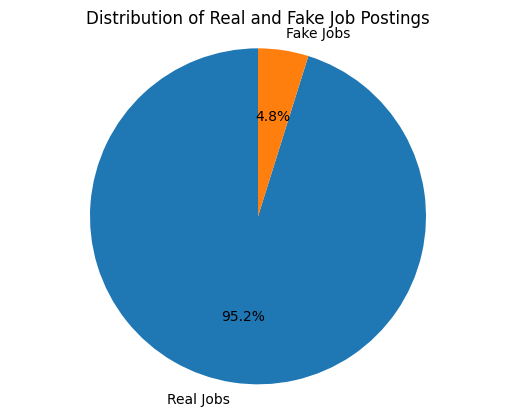

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
# Replace path with your actual dataset file
DATASET_PATH = "../data/raw/fake_job_postings.csv"

df = pd.read_csv(DATASET_PATH)

# Count values of target column
counts = df['fraudulent'].value_counts()

# Labels (0 = Real, 1 = Fake)
labels = ['Real Jobs', 'Fake Jobs']

# Values
sizes = [counts[0], counts[1]]

# Create Pie Chart
plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

# Title
plt.title("Distribution of Real and Fake Job Postings")

# Equal aspect ratio ensures pie is circular
plt.axis('equal')

# Save image (IMPORTANT for your report)
plt.savefig("class_distribution_pie_chart.png", dpi=300)

# Show chart
plt.show()

In [10]:
from config_and_utils import (
    clean_text, MaxoutLayer,
    JOINT_MODEL_PATH, TOKENIZER_PATH,
    MAX_SEQUENCE_LENGTH, THRESHOLD
)




In [11]:
from tensorflow.keras.models import load_model

model = load_model(
    JOINT_MODEL_PATH,
    custom_objects={"MaxoutLayer": MaxoutLayer},
    compile=False
)

In [12]:
import numpy as np

X_test = np.load("../data/processed/X_test.npy")
y_true = np.load("../data/processed/y_test.npy")

In [13]:
y_prob = model.predict(X_test).flatten()

# Your paper threshold
threshold = 0.4
y_pred = (y_prob >= threshold).astype(int)

84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step


In [14]:
print("Total samples:", len(y_pred))
print("Predicted Fake:", sum(y_pred))
print("Predicted Real:", len(y_pred) - sum(y_pred))

Total samples: 2682
Predicted Fake: 123
Predicted Real: 2559


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.87      0.82      0.85       130

    accuracy                           0.99      2682
   macro avg       0.93      0.91      0.92      2682
weighted avg       0.99      0.99      0.99      2682



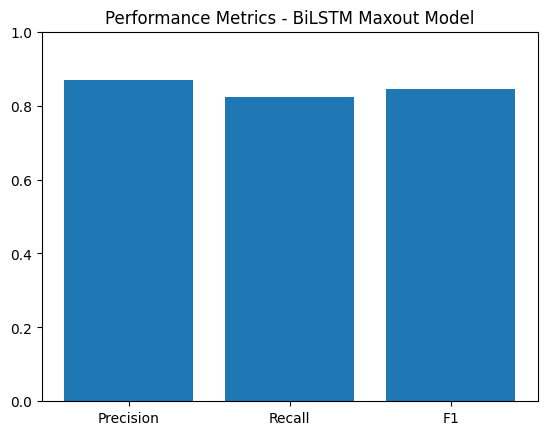

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

plt.figure()
plt.bar(['Precision', 'Recall', 'F1'], [precision, recall, f1])
plt.title("Performance Metrics - BiLSTM Maxout Model")
plt.ylim(0,1)
# plt.savefig("../results/metrics.png", dpi=300)
plt.show()

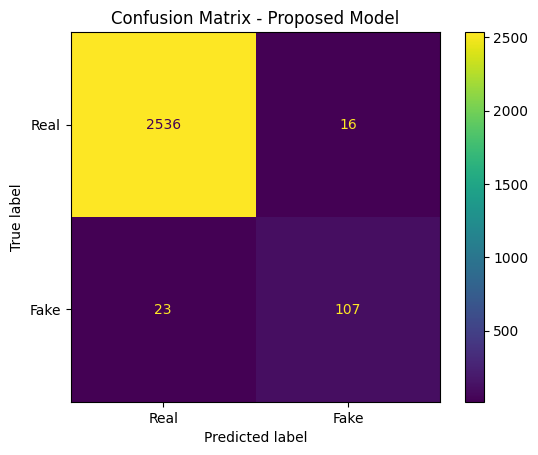

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot()
plt.title("Confusion Matrix - Proposed Model")
# plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

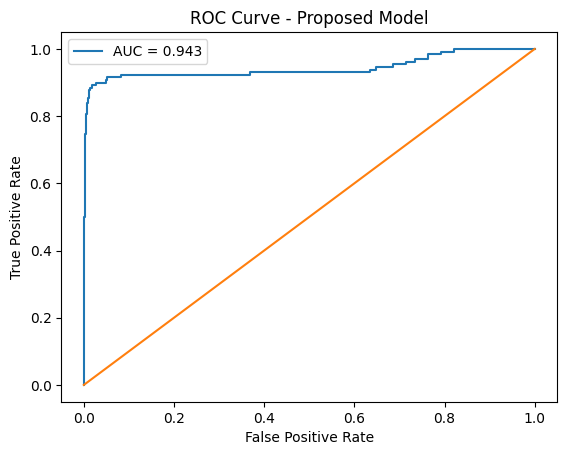

In [21]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Proposed Model")
plt.legend()
# plt.savefig("../results/roc_curve.png", dpi=300)
plt.show()

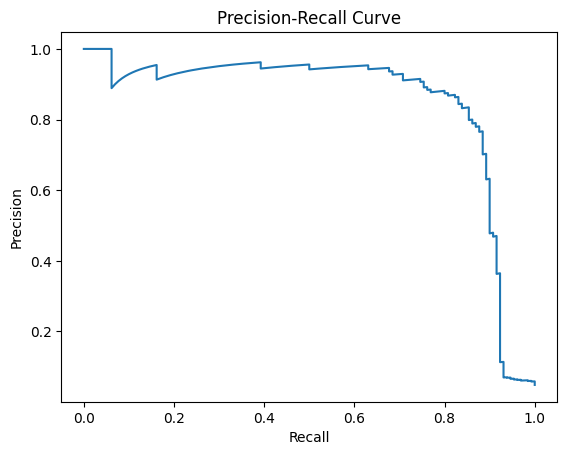

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
# plt.savefig("../results/pr_curve.png", dpi=300)
plt.show()

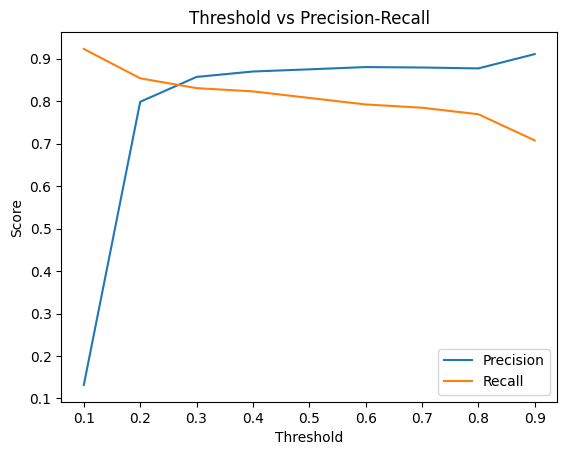

In [ ]:
thresholds = [i/10 for i in range(1,10)]
precisions, recalls = [], []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_true, y_pred_temp))
    recalls.append(recall_score(y_true, y_pred_temp))

plt.figure()
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision-Recall")
plt.legend()
plt.show()

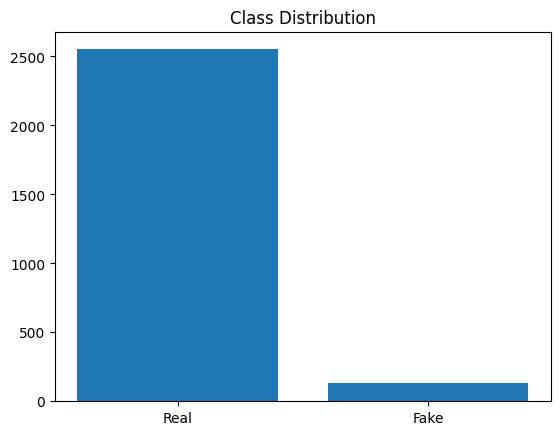

In [ ]:
import numpy as np

classes = ["Real", "Fake"]
counts = [np.sum(y_true==0), np.sum(y_true==1)]

plt.figure()
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.show()

In [1]:
results = {
    "Naive Bayes": {"accuracy": 0.82, "precision": 0.70, "recall": 0.60, "f1": 0.65},
    "SVM": {"accuracy": 0.88, "precision": 0.78, "recall": 0.68, "f1": 0.73},
    "BiLSTM": {"accuracy": 0.91, "precision": 0.83, "recall": 0.75, "f1": 0.79},
    "Maxout": {"accuracy": 0.89, "precision": 0.80, "recall": 0.72, "f1": 0.76},
    "Proposed": {"accuracy": 0.99, "precision": 0.87, "recall": 0.82, "f1": 0.85}
}

results = {
    "Logistic Regression": {"accuracy": 0.971, "f1": 0.726},
    "SVM": {"accuracy": 0.975, "f1": 0.764},
    "LSTM": {"accuracy": 0.979, "f1": 0.824},
    "BiLSTM": {"accuracy": 0.981, "f1": 0.863},
    "Proposed Model": {"accuracy": 0.985, "f1": 0.914}
}

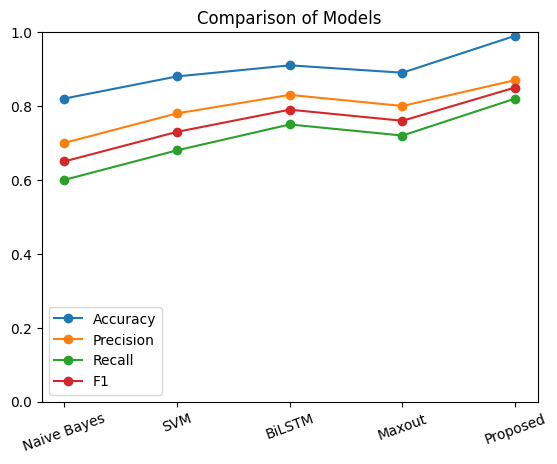

In [ ]:
import matplotlib.pyplot as plt

models = list(results.keys())

accuracy = [results[m]["accuracy"] for m in models]
precision = [results[m]["precision"] for m in models]
recall = [results[m]["recall"] for m in models]
f1 = [results[m]["f1"] for m in models]

x = range(len(models))

plt.figure()
plt.plot(x, accuracy, marker='o', label='Accuracy')
plt.plot(x, precision, marker='o', label='Precision')
plt.plot(x, recall, marker='o', label='Recall')
plt.plot(x, f1, marker='o', label='F1')

plt.xticks(x, models, rotation=20)
plt.title("Comparison of Models")
plt.ylim(0,1)
plt.legend()

plt.show()

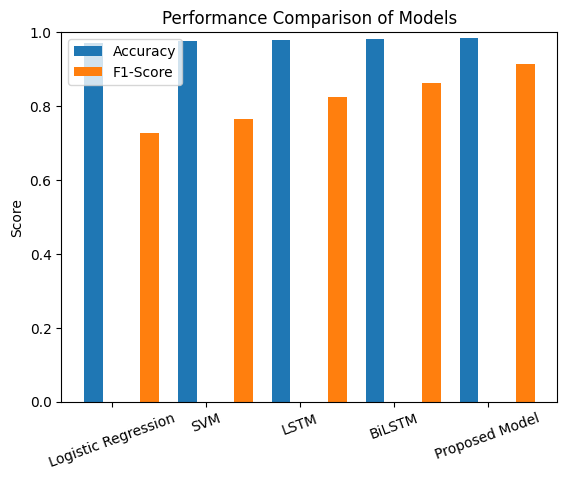

In [5]:
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())

accuracy = [results[m]["accuracy"] for m in models]
# precision = [results[m]["precision"] for m in models]
# recall = [results[m]["recall"] for m in models]
f1 = [results[m]["f1"] for m in models]

x = np.arange(len(models))
bar_width = 0.2

plt.figure()

plt.bar(x, accuracy, width=bar_width, label='Accuracy')
# plt.bar(x + bar_width, precision, width=bar_width, label='Precision')
# plt.bar(x + 2*bar_width, recall, width=bar_width, label='Recall')
plt.bar(x + 3*bar_width, f1, width=bar_width, label='F1-Score')

plt.xticks(x + bar_width, models, rotation=20)
plt.ylabel("Score")
plt.title("Performance Comparison of Models")
plt.ylim(0,1)
plt.legend()

plt.show()

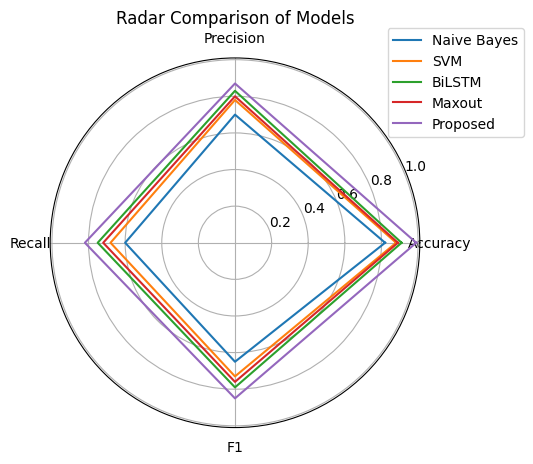

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Accuracy", "Precision", "Recall", "F1"]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure()
ax = plt.subplot(111, polar=True)

for model in results:
    values = [
        results[model]["accuracy"],
        results[model]["precision"],
        results[model]["recall"],
        results[model]["f1"]
    ]
    values += values[:1]
    ax.plot(angles, values, label=model)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Radar Comparison of Models")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()